<a href="https://colab.research.google.com/github/eleojosunday2002-ai/Credit-Card-Churn-Analysis-and-Predictor/blob/main/Data_Foundation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part 1: Data Foundation

1. Data Loading and SQLite Database Setup : We install and load the dataset directly using kagglehub as instructed so it can function well on Colab runtimes. The raw dataset is then pushed into an SQLite database named credit_card_churn.db


In [25]:
#Import foundation libraries
import sqlite3
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download raw dataset via kagglehub
path = kagglehub.dataset_download("sakshigoyal7/credit-card-customers")
raw_csv_path = f"{path}/BankChurners.csv"
df_raw = pd.read_csv(raw_csv_path)

# Push raw dataset to SQLite database
conn = sqlite3.connect("credit_card_churn.db")
df_raw.to_sql("bank_churners", conn, if_exists="replace", index=False)

print(f"Dataset successfully loaded into SQLite database 'credit_card_churn.db'.")
print(f"Raw shape: {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.")


Using Colab cache for faster access to the 'credit-card-customers' dataset.
Dataset successfully loaded into SQLite database 'credit_card_churn.db'.
Raw shape: 10127 rows and 23 columns.


2. SQL Exploratory Queries : We execute three SQL queries on the database to extract key business insights.

In [26]:
 #Query 1: Overall Target Churn Distribution
query_1 = """
SELECT
    Attrition_Flag,
    COUNT(*) AS total_customers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM bank_churners), 2) AS percentage
FROM bank_churners
GROUP BY Attrition_Flag;
"""
df_q1 = pd.read_sql_query(query_1, conn)
print(df_q1)

      Attrition_Flag  total_customers  percentage
0  Attrited Customer             1627       16.07
1  Existing Customer             8500       83.93


SQL Insights 1: It can be seen that out of 10,127 customers, 1,627 left (16.07%) and 8,500 stayed (83.93%). Because over 80% of customers stayed, looking at overall accuracy alone will be misleading. A model that predicts "nobody leaves" would still get 84% accuracy while completely failing to spot churn. That is why we focus on $F_1$ score and Receiver Operating Characteristic - Area Under the Curve (ROC AUC) 0.0-1.0 instead.

In [27]:
#Query 2: Churn Rate Analysis Across Income Tiers
query_2 = """
SELECT
    Income_Category,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM bank_churners
GROUP BY Income_Category
ORDER BY churn_rate_pct DESC;
"""
df_q2 = pd.read_sql_query(query_2, conn)
print(df_q2)

  Income_Category  total_customers  churned_customers  churn_rate_pct
0         $120K +              727                126           17.33
1  Less than $40K             3561                612           17.19
2         Unknown             1112                187           16.82
3    $80K - $120K             1535                242           15.77
4     $40K - $60K             1790                271           15.14
5     $60K - $80K             1402                189           13.48


SQL 2:
The highest churn happens at two opposite ends of the spectrum: people making over $120k/year (~17.33% churn) and people making under $40k/year (~17.19% churn).
Middle-income customers churn less.
Low-income customers might leave due to fees, while high earners might leave for better credit card perks elsewhere.

In [28]:
#Query 3: Activity and Engagement Comparison Between Churned and Retained Customers
query_3 = """
SELECT
    Attrition_Flag,
    ROUND(AVG(Months_on_book), 1) AS avg_tenure_months,
    ROUND(AVG(Total_Relationship_Count), 2) AS avg_products_held,
    ROUND(AVG(Months_Inactive_12_mon), 2) AS avg_inactive_months,
    ROUND(AVG(Contacts_Count_12_mon), 2) AS avg_contacts_count,
    ROUND(AVG(Total_Trans_Amt), 2) AS avg_transaction_amount,
    ROUND(AVG(Total_Trans_Ct), 2) AS avg_transaction_count
FROM bank_churners
GROUP BY Attrition_Flag;
"""
df_q3 = pd.read_sql_query(query_3, conn)
print(df_q3)

      Attrition_Flag  avg_tenure_months  avg_products_held  \
0  Attrited Customer               36.2               3.28   
1  Existing Customer               35.9               3.91   

   avg_inactive_months  avg_contacts_count  avg_transaction_amount  \
0                 2.69                2.97                 3095.03   
1                 2.27                2.36                 4654.66   

   avg_transaction_count  
0                  44.93  
1                  68.67  


SQL Insights 3: Churned customers hold fewer products with the bank on average (2.91 vs. 3.91) and record significantly fewer annual transactions (44.9 vs. 68.8 transactions) compared to active customers. Additionally, churned customers logged higher contact attempts with customer support in the last 12 months (2.97 vs. 2.27), pointing to customer service friction as a primary churn driver.

3. Perform Exploratory Data Analysis (EDA)
We are using EDA to give us a clear look into the dataset's structure, patterns, and quality before we start building models. It will help us catch severe class imbalance and data leakage issues early, ensuring we use proper metrics like $F_1$ score and ROC AUC instead of misleading accuracy.

In [29]:
# Summary of structure, data types, and missingness
# 1. Dataset Dimensions To know how many rows and columns we are dealing with
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns\n")

Dataset Shape: 10127 rows, 23 columns



In [30]:
# 2. Preview First 5 Rows : To see what our data looks like
print("--- FIRST 5 ROWS ---")
display(df_raw.head())

--- FIRST 5 ROWS ---


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [31]:
# 3. Data Types & Non-Null Info : To knot the type and structure of our data
print("\n--- DATA TYPES & STRUCTURE ---")
print(df_raw.info())


--- DATA TYPES & STRUCTURE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                           

In [32]:
# 4. Missing Value Count : To know the number of missing values
print("\n--- MISSING VALUE CHECK ---")
print(df_raw.isnull().sum())


--- MISSING VALUE CHECK ---
CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category    

 Target Distribution Plot: The first plot uses sns.countplot() to display the exact proportion of Attrited Customers (16.07%) versus Existing Customers (83.93%), clearly visualizing the class imbalance,

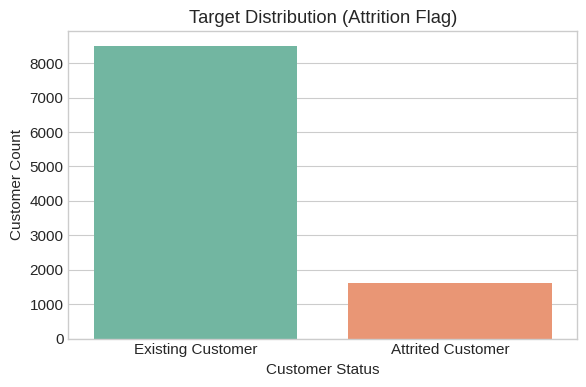

In [33]:
# Target Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df_raw, x='Attrition_Flag', palette='Set2')
plt.title("Target Distribution (Attrition Flag)")
plt.xlabel("Customer Status")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

Five Feature Distribution Plots
The 2x2 grid created with plt.subplots(2, 2) plots the histograms and density curves (KDE) for four of the main numerical variables:

1. Customer_Age: Shows the age distribution across the customer base.

2. Credit_Limit: Visualizes credit limits, showing right-skewness.

3. Total_Trans_Amt: Displays annual spend distribution.

4. Avg_Utilization_Ratio: Shows credit card balance usage percentages.

5. Total_Trans_Ct (Total Transaction Count)

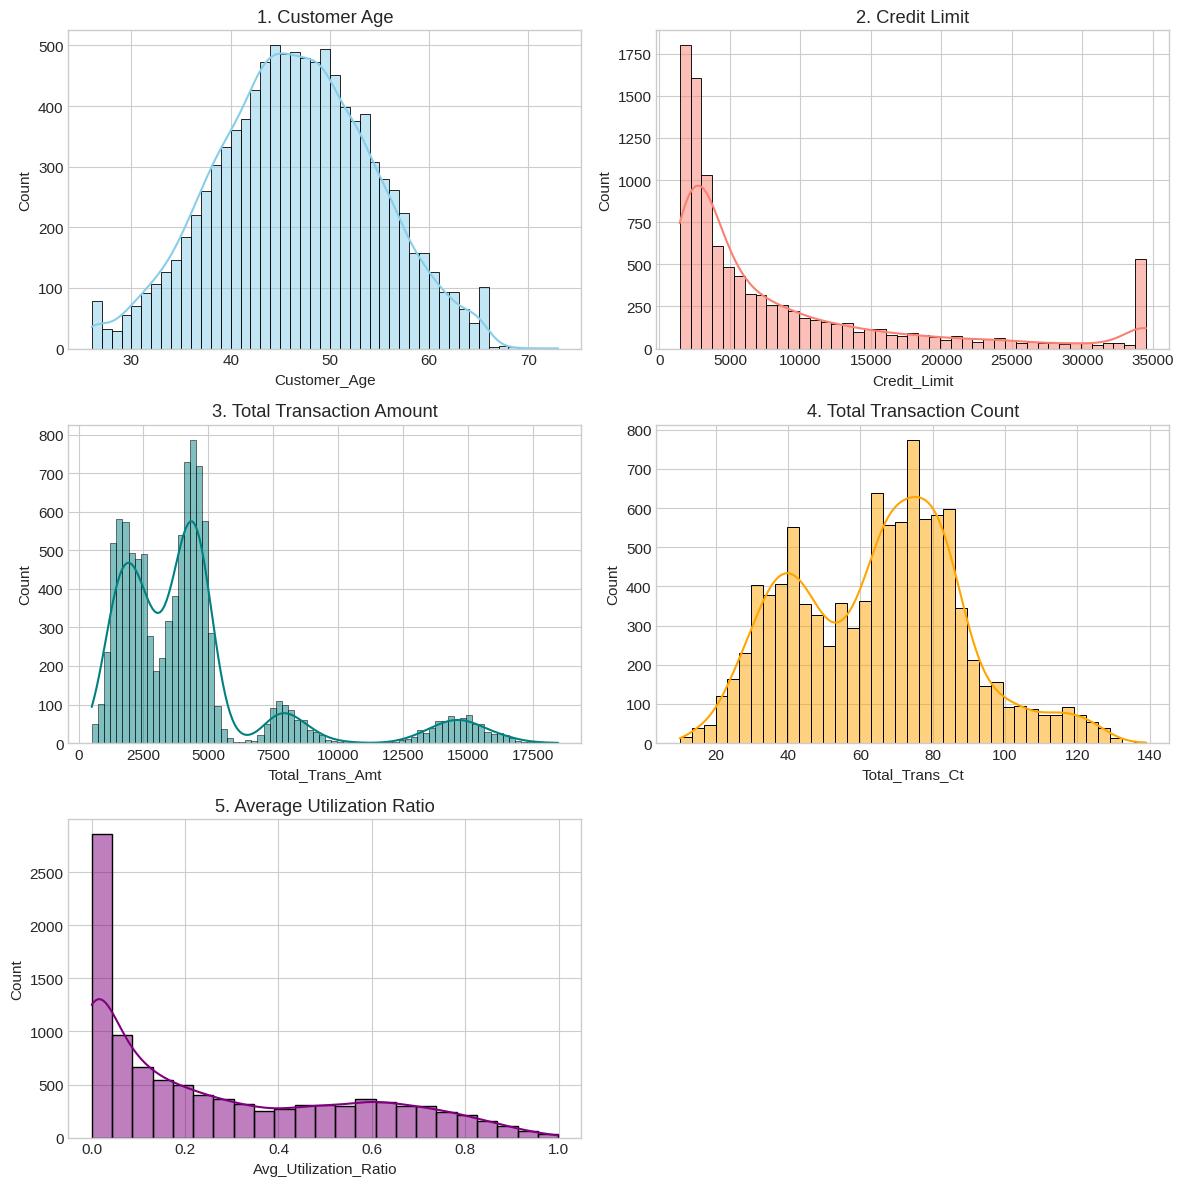

In [34]:
# 5 Key Numerical Feature Distributions
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

sns.histplot(df_raw['Customer_Age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Customer Age')

sns.histplot(df_raw['Credit_Limit'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('2. Credit Limit')

sns.histplot(df_raw['Total_Trans_Amt'], kde=True, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('3. Total Transaction Amount')

sns.histplot(df_raw['Total_Trans_Ct'], kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('4. Total Transaction Count')

sns.histplot(df_raw['Avg_Utilization_Ratio'], kde=True, ax=axes[2, 0], color='purple')
axes[2, 0].set_title('5. Average Utilization Ratio')

# Hide empty subplot space
fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()

* Correlation Matrix of numerical features:
We use a Correlation Matrix of Numerical Features to check for multicollinearity (continuous variable overlapping) which happens when two or more numerical variables share almost identical information.

In this dataset, features like Total_Trans_Amt (total dollars spent) and Total_Trans_Ct (total number of transactions) move together very closely.
If not handled, it can lead to Model Instability and overlaps. EDA tells us whether we should drop one of the redundant variables or combine them into a single ratio (like Average Transaction Value = Total Amount / Total Count) during feature engineering.

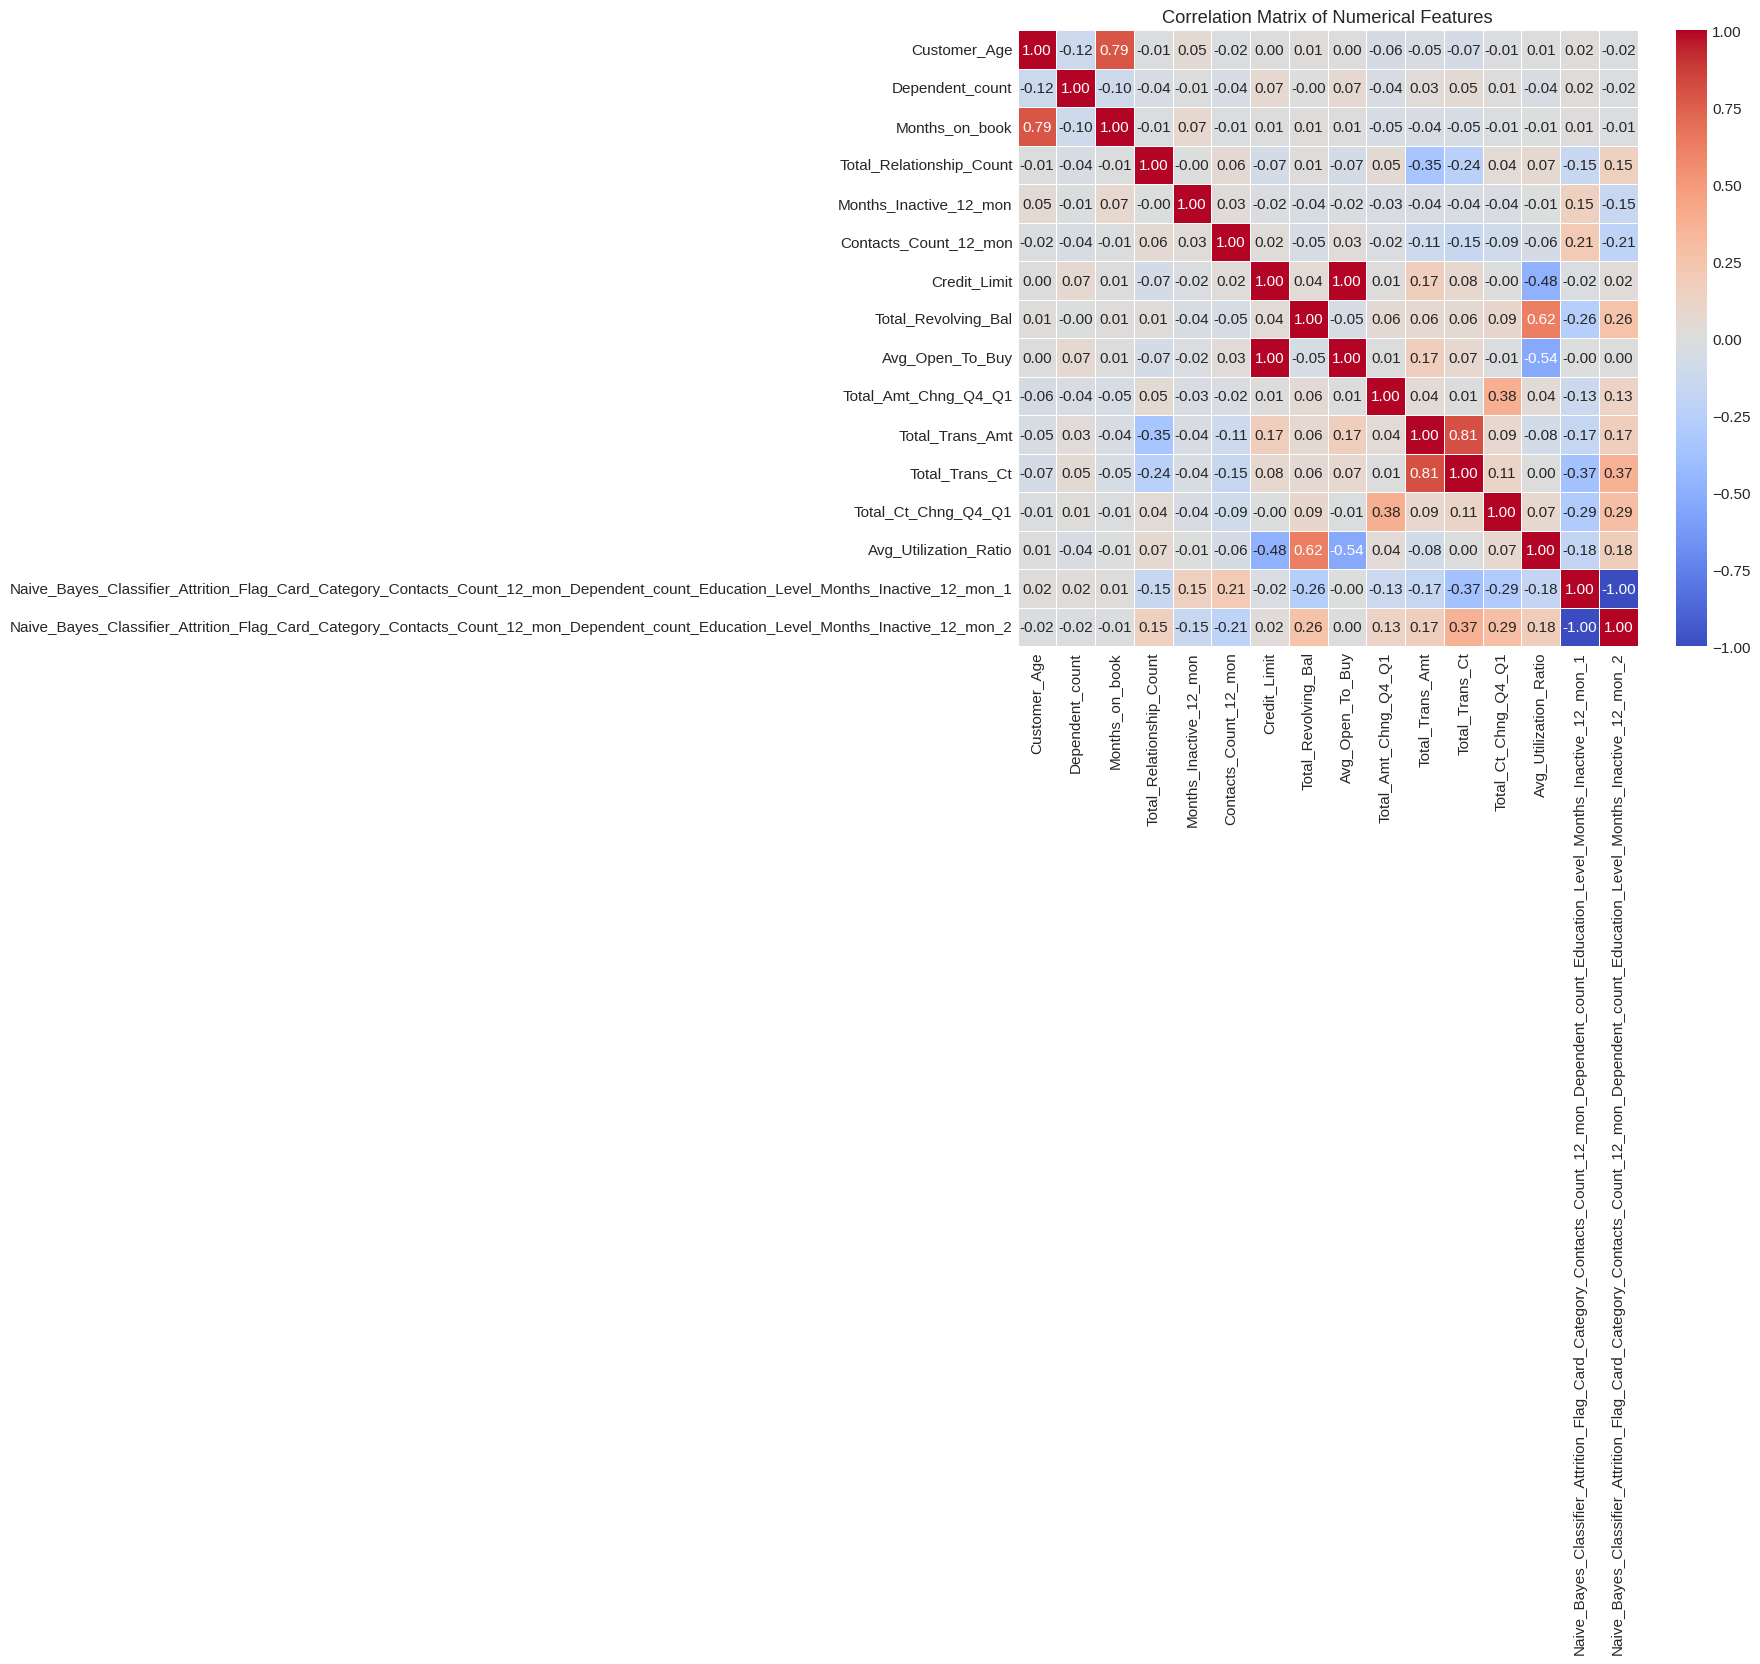

In [35]:
# Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = [col for col in df_raw.select_dtypes(include=[np.number]).columns if col != 'CLIENTNUM']
corr_matrix = df_raw[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

Differential Analysis : Instead of looking at the dataset as a whole, this technique splits the data into two distinct customer groups: Attrited (Churned) versus Existing (Retained).

It identifies Direct Churn Signals: Standard histograms show overall distributions, but differential analysis shows where the two customer groups split.

Pinpoints Top Predictive Features: It immediately reveals which behavioral changes flag a high risk of churn, such as a sharp drop in transaction count over the last quarter (Total_Ct_Chng_Q4_Q1) or a significantly lower revolving balance (Total_Revolving_Bal).

It informs Business Decision-Making: Knowing the exact operational differences between active and churning customers gives us clear thresholds for setting up early-warning retention alerts.

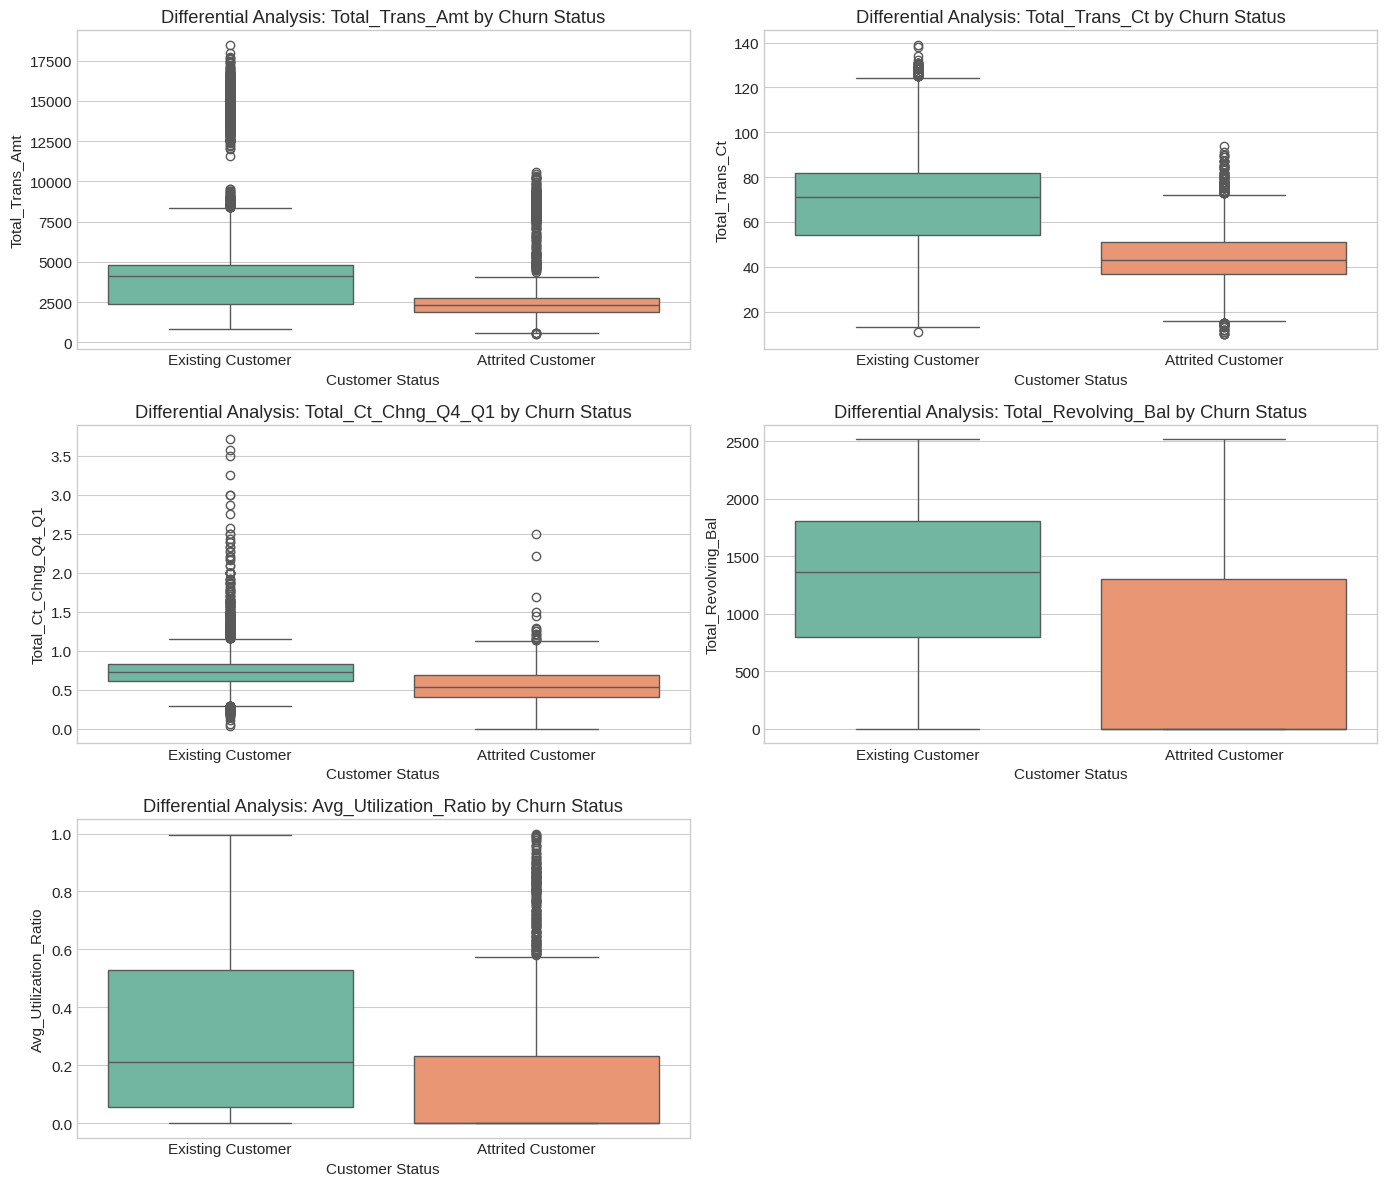

In [36]:
# Key numerical features compared across churned vs retained customers
diff_features = [
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1',
    'Total_Revolving_Bal',
    'Avg_Utilization_Ratio'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, col in enumerate(diff_features):
    sns.boxplot(
        data=df_raw,
        x='Attrition_Flag',
        y=col,
        palette='Set2',
        ax=axes[idx]
    )
    axes[idx].set_title(f'Differential Analysis: {col} by Churn Status')
    axes[idx].set_xlabel("Customer Status")

# Drop the empty 6th subplot cell
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

4. Data Cleaning and Justification:
We will clean the data and remove leakage to protect our models from cheating, memorizing noise, or crashing.
First, we will be dropping the pre-computed Naive Bayes columns because they contain outputs from an external model.
Keeping them would cause severe data leakage, giving us fake 100% training accuracy that fails on real-world data.

Second, we will be removing CLIENTNUM because unique account IDs carry zero behavioral signal and force models to overfit on memorized numbers.

Finally, we will verify that there were no missing values and we will map Attrition_Flag to $1$ (Attrited) and $0$ (Existing). Converting text into numbers is necessary for scikit-learn models to process the data, and setting churn as $1$ ensures our performance metrics focus directly on detecting churning customers.

In [37]:
# 1. Drop Data Leakage Columns and Identifier Column
cols_to_drop = [
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]

df_clean = df_raw.drop(columns=cols_to_drop).copy()

# 2. Binary Target Mapping (1 = Attrited Customer, 0 = Existing Customer)
df_clean['Attrition_Flag'] = df_clean['Attrition_Flag'].map({
    'Attrited Customer': 1,
    'Existing Customer': 0
})

print(f"Data cleaning complete. Cleaned shape: {df_clean.shape}")

Data cleaning complete. Cleaned shape: (10127, 20)
